# Statistical Modeling and Evaluation

---

## Overview

This notebook demonstrates the full pipeline for building and evaluating regression models on a real insurance dataset.

**Business Goal:** Predict annual medical insurance charges for a customer based on their age, sex, BMI, number of children, smoking status, and region.

**Why this matters:** In the insurance industry, the predicted charge directly informs the premium a customer is charged. An accurate model means the company prices risk correctly — not too low (which causes losses) and not too high (which drives customers away).

---

## Dataset: Medical Insurance Charges

| Column | Type | Description |
|---|---|---|
| `age` | Numerical | Customer's age in years |
| `sex` | Categorical | Gender: `female` or `male` |
| `bmi` | Numerical | Body Mass Index — weight/height² — a health risk indicator |
| `children` | Numerical | Number of dependents covered by the policy |
| `smoker` | Categorical | Whether the customer smokes: `yes` or `no` |
| `region` | Categorical | US region: `northeast`, `northwest`, `southeast`, `southwest` |
| `charges` | Numerical **(Target)** | Annual medical charges billed — **what we predict** |

---

## Notebook Structure

| Section | What We Do |
|---|---|
| 1 | Setup: import libraries and custom scripts |
| 2 | Load and clean raw data |
| 3 | Encode categorical variables into numbers |
| 4 | Scale numerical variables |
| 5 | Split data into training and testing sets |
| 6 | Train four regression models |
| 7 | Evaluate and compare models (MAE, MSE, R²) |
| 8 | Visualise decision trees |
| 9 | Plot feature importance |
| 10 | Hyperparameter tuning with GridSearchCV |
| 11 | Apply and evaluate the best tuned model |
| 12 | Print and interpret decision rules |

In [6]:
# sys — allows Python to interact with the system, especially things like the module search path.
# os — used for path handling (important for loading files and scripts).
# pandas (pd) — a powerful library for loading, cleaning, transforming, and analyzing data.
# datetime — handles date and time values (not used here but often part of data pipelines).

In [7]:
import sys
import os
import pandas as pd
from datetime import datetime

In [8]:
# Add the '../scripts' directory to the Python module search path.
# This allows us to import modules from that directory, 
# facilitating better organization of our code and access to shared scripts.
sys.path.append(os.path.abspath('../scripts'))

In [9]:
# We import two custom Python files you created:
# data_processing.py → handles loading, encoding, scaling
# model.py → handles model training, evaluation, plotting
# This maintains modularity and clean project structure.

import data_processing as dp
import model as m

---
## Section 1 — Setup

We import two types of libraries:

**Standard libraries**
- `sys` and `os` — needed to tell Python where our custom scripts live
- `pandas` — for loading and manipulating data tables (DataFrames)

**Custom scripts** (our own `.py` files in the `scripts/` folder)
- `data_processing` → handles loading, encoding, and scaling
- `model` → handles training, evaluating, and plotting models

Using separate script files instead of writing everything in the notebook keeps the code **modular** — easy to reuse, test, and maintain.

---
## Section 2 — Load and Clean Data

We use our custom `load_and_clean_data()` function which does two things:
1. **Reads** the CSV file into a pandas DataFrame
2. **Removes duplicate rows** — rows that are exact copies of another row

**Why remove duplicates?**
Duplicate records bias the model. If a customer record appears twice, the model sees that pattern twice during training and gives it more weight than it deserves. The original dataset has 1,338 rows — after removing 1 duplicate, we have **1,337 rows**.

In [10]:
filepath = '../data/insurance.csv'
data = dp.load_and_clean_data(filepath)
data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


---
## Section 3 — Encoding Categorical Variables

### Why Encoding is Necessary
Machine learning models do mathematics — multiplication, addition, distance calculations. They **cannot do math on text**. A column containing `"male"` and `"female"` must be converted to numbers before the model can use it.

### Method Used: Label Encoding

Assigns a unique integer to each unique category value.

| Original Value | Encoded Value |
|---|---|
| `female` | 0 |
| `male` | 1 |
| `no` (smoker) | 0 |
| `yes` (smoker) | 1 |
| `northeast` | 0 |
| `northwest` | 1 |
| `southeast` | 2 |
| `southwest` | 3 |

**When to use Label Encoding:** Works best with tree-based models (Decision Tree, Random Forest, XGBoost) because trees split on threshold values — they do not assume the numbers imply any order.

> **Note:** For linear models, use One-Hot Encoding for columns with more than 2 categories (like `region`), because linear models would treat 0 < 1 < 2 < 3 as meaningful order, which is wrong for regions.

🔹 What is encoding?

Machine learning models cannot understand text (categorical data),
so we convert them into numbers.

🔹 Label Encoding

Converts each category → a number

Example: "male"=0, "female"=1

Why?

Most ML models need numerical inputs.

In [11]:
columns_label = ['sex', 'smoker', 'region']
columns_onehot = ['sex', 'smoker', 'region', 'children']

df_label = dp.encoder('labelEncoder', data, columns_label, columns_onehot)
df_label

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


---
### Section 3b — Scaling the Target Variable

### Why Scaling is Necessary
`charges` ranges from **£1,122 to £63,770** — a very wide and skewed range. Without scaling, models that use gradient descent can struggle with such large numbers and train slowly or unstably.

### Method Used: Min-Max Scaling

Maps every value to the range **[0, 1]** using the formula:

```
scaled = (value - minimum) / (maximum - minimum)
```

**Examples:**
- `charges = 1,122` (minimum) → scaled = **0.0**
- `charges = 63,770` (maximum) → scaled = **1.0**
- `charges = 32,000` → scaled ≈ **0.49**

**Important:** All evaluation metrics (MAE, MSE, R²) in this notebook are on the **scaled 0–1 range**. To convert MAE back to real pounds:

```
MAE in £ = MAE_scaled × (max_charge - min_charge)
         = 0.041 × (63,770 - 1,122)
         ≈ £2,576
```

In [12]:
columns_scaler = ['charges']
df_scaled = dp.scaler('minMaxScaler', df_label, columns_scaler)
df_scaled

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,0.251611
1,18,1,33.770,1,0,2,0.009636
2,28,1,33.000,3,0,2,0.053115
3,33,1,22.705,0,0,1,0.333010
4,32,1,28.880,0,0,1,0.043816
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,0.151299
1334,18,0,31.920,0,0,0,0.017305
1335,18,0,36.850,0,0,2,0.008108
1336,21,0,25.800,0,0,3,0.014144


---
## Section 4 — Train-Test Split

### The Golden Rule of Machine Learning
**Never test your model on data it was trained on.**

If you train and evaluate on the same data, the model appears perfectly accurate because it has already memorised the answers. This is called **overfitting** — the model memorises instead of learning.

The test set simulates **brand-new, unseen customers** — giving you an honest measurement of how the model performs in the real world.

### Split Details

| Set | Size | Purpose |
|---|---|---|
| **Training set** | 1,069 rows (80%) | The model learns patterns from this data |
| **Test set** | 268 rows (20%) | Evaluate how well the model predicts on new data |

- `X` = all feature columns (age, sex, bmi, children, smoker, region) — the **inputs**
- `y` = the `charges` column — the **output we want to predict**
- `random_state=42` ensures the same rows go to train/test every time you run the notebook (reproducibility)

X = all independent variables (features).

y = target variable (charges).

Train-test split:

Train set → used to train the model

Test set → used to evaluate the model on unseen data

This prevents overfitting.

In [13]:
X = df_scaled.drop('charges', axis=1)
y = df_scaled['charges']

X_train, X_test, y_train, y_test = m.split_data(X, y)
X_train


,age,sex,bmi,children,smoker,region
1114,23,1,24.510,0,0,0
968,21,1,25.745,2,0,0
599,52,0,37.525,2,0,1
170,63,1,41.470,0,0,2
275,47,0,26.600,2,0,0
...,...,...,...,...,...,...
1096,51,0,34.960,2,1,0
1131,27,1,45.900,2,0,3
1295,20,1,22.000,1,0,3
861,38,0,28.000,3,0,3


---
## Section 5 — Training the Models

We train **four regression models** on the same training data and compare them. Each model takes a different approach to learning the relationship between features and charges.

| Model | Type | How It Learns |
|---|---|---|
| **Linear Regression** | Parametric | Finds β coefficients for a straight-line formula: `charges = β₀ + β₁·age + β₂·bmi + ...` |
| **Decision Tree** | Nonparametric | Builds if/else rules: *"If smoker=1 AND age > 45, predict high charges"* |
| **Random Forest** | Ensemble (100 trees) | Builds 100 independent trees on random data subsets and averages predictions |
| **XGBoost** | Gradient Boosting | Builds trees sequentially — each tree corrects the errors of the previous one |

### The Training Step: `.fit(X_train, y_train)`
This single call is the entire learning process. The model reads the training features (`X_train`) and their known outcomes (`y_train`) and adjusts its internal parameters to minimise prediction error.

After `.fit()` completes, the model is ready to predict charges for customers it has never seen before.

We train four models:

Linear Regression → simplest model, finds a straight-line relationship

Decision Tree Regressor → splits data based on rules

Random Forest Regressor → many trees averaged together

XGBoost Regressor → powerful boosting algorithm, great accuracy

Training means:
→ the model learns patterns in the training data.

In [14]:
lr_model, dt_model, rfr_model, xgb_model = m.train_models(X_train, y_train)

---
## Section 6 — Evaluation

We measure each model's performance on the **test set** (data it never saw during training) using three metrics.

### The Three Metrics Explained

**MAE — Mean Absolute Error**
```
MAE = average of |actual_charge - predicted_charge| for all test rows
```
- **What it tells you:** On average, how far off is each prediction?
- **Units:** Same as the target (scaled 0–1 here; multiply by £62,648 to get real pounds)
- **Lower is better**

**MSE — Mean Squared Error**
```
MSE = average of (actual_charge - predicted_charge)² for all test rows
```
- **What it tells you:** How much do large errors hurt us? Squaring means a £10,000 error is penalised 100x more than a £1,000 error
- **Why this matters in insurance:** Severely underpricing a high-risk policy is catastrophic — MSE captures this asymmetry
- **Lower is better**

**R² — Coefficient of Determination**
```
R² = 1 - (unexplained variance / total variance in charges)
```
- **What it tells you:** What fraction of the variation in charges does the model explain?
- **R² = 0.88** means the model explains **88% of why charges differ** between customers
- **Range:** 0 to 1. Closer to 1 = better. Below 0 = model is worse than just predicting the mean

### What to Expect
| Model | Expected Strength |
|---|---|
| Linear Regression | Solid baseline — interpretable but limited |
| Decision Tree | Good on average cases, can make large errors (overfits) |
| Random Forest | Best overall — high R², low MSE |
| XGBoost | Close to Random Forest, sometimes better after tuning |

You compute 3 important metrics:
1. MAE (Mean Absolute Error)

Average of |prediction – actual|
→ How far off we are, on average

2. MSE (Mean Squared Error)

Squares the error → penalizes large errors heavily
→ Useful when big mistakes are expensive (like insurance)

3. R² Score

How much variance the model can explain
→ Higher is better (closer to 1)

In [15]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost']
mae_scores, mse_scores, r2_scores = [], [], []

for model in [lr_model, dt_model, rfr_model, xgb_model]:
    mae, mse, r2, _ = m.evaluate_model(model, X_test, y_test)
    mae_scores.append(mae)
    mse_scores.append(mse)
    r2_scores.append(r2)


In [16]:
# Prints the performance of each model so we can compare them.
for i, model_name in enumerate(models):
    print(f"Evaluation results for {model_name}:")
    print(f" - Mean Absolute Error (MAE): {mae_scores[i]}")
    print(f" - Mean Squared Error (MSE): {mse_scores[i]}")
    print(f" - R-squared (R2) Score: {r2_scores[i]}")
    print("\n")


Evaluation results for Linear Regression:
 - Mean Absolute Error (MAE): 0.06675897336664484
 - Mean Squared Error (MSE): 0.009043194261536826
 - R-squared (R2) Score: 0.8068466322629111


Evaluation results for Decision Tree:
 - Mean Absolute Error (MAE): 0.04766572578809052
 - Mean Squared Error (MSE): 0.010701816175810322
 - R-squared (R2) Score: 0.7714201668703586


Evaluation results for Random Forest:
 - Mean Absolute Error (MAE): 0.041096956922102405
 - Mean Squared Error (MSE): 0.005505724728721087
 - R-squared (R2) Score: 0.8824033585445589


Evaluation results for XGBoost:
 - Mean Absolute Error (MAE): 0.04504134370434591
 - Mean Squared Error (MSE): 0.00616446587764255
 - R-squared (R2) Score: 0.8683333222607694




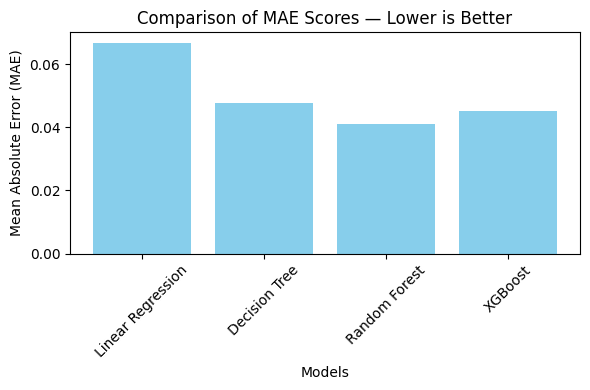

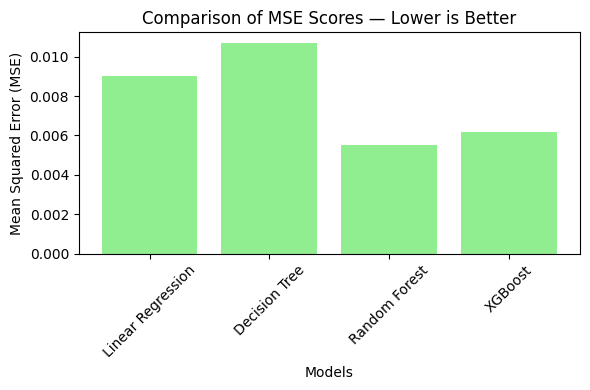

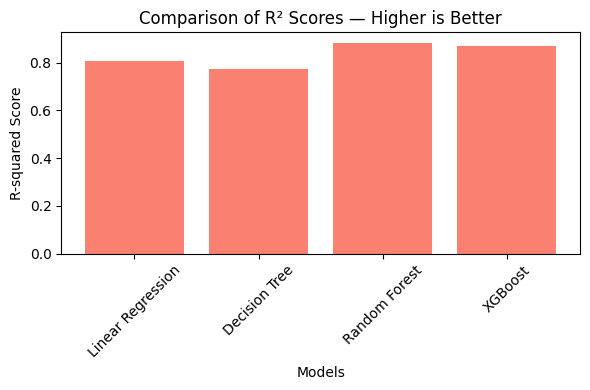

In [17]:
# Creates bar charts comparing model performance.
# Visual comparison is easier for presentations.

m.plot_metrics(models, mae_scores, mse_scores, r2_scores)

---
## Section 7 — Decision Tree Visualisation

A Decision Tree makes predictions by asking a series of yes/no questions about the input features. The visualisation shows every question the model asks.

### How to Read the Tree

- **Each internal node (box with a condition):** A split decision — e.g., `smoker <= 0.5` means *"is this person a non-smoker?"*
- **Left branch:** The condition is TRUE
- **Right branch:** The condition is FALSE
- **Each leaf node (bottom box):** The final predicted charge value for customers who reach that branch
- **Colour intensity:** Darker = the model is more confident (less variance at that leaf)


This is model **interpretability** — you can read exactly what rule the model is applying and explain it to a business stakeholder or regulator.

Shows the structure of a Decision Tree:

- Each node represents a decision

- Leaf nodes represent predicted charges

- Helps explain model logic (interpretability)

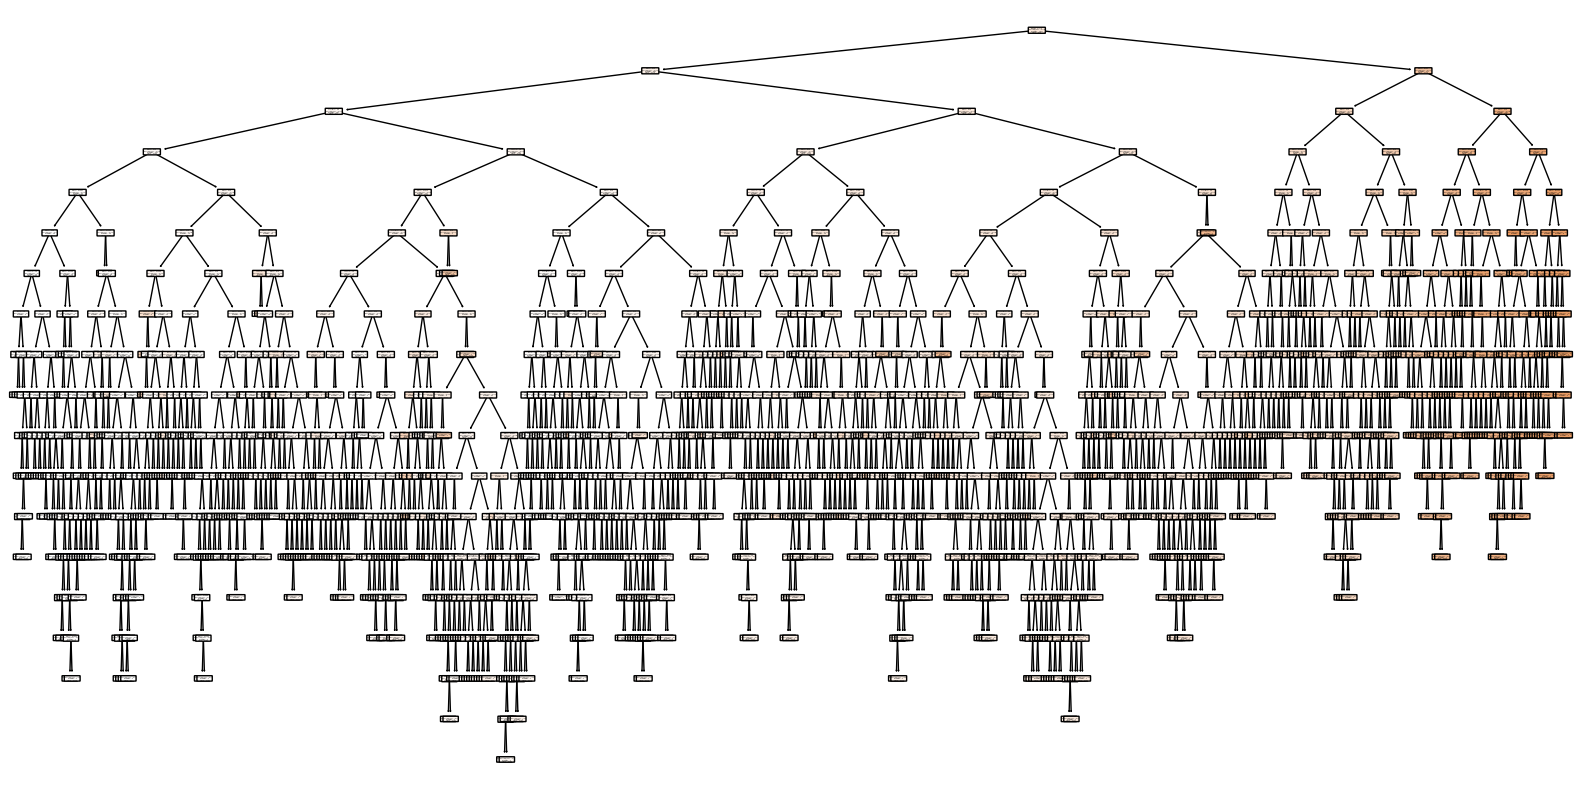

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(decision_tree=dt_model, feature_names=X_train.columns, filled=True, rounded=True)
plt.show()

---
## Section 8 — Random Forest: Visualising Individual Trees

A Random Forest contains many decision trees (100 by default). Here we extract and visualise individual trees from inside the forest.


Random Forest has many decision trees.

Here, you visualize one tree to understand how the forest decides.

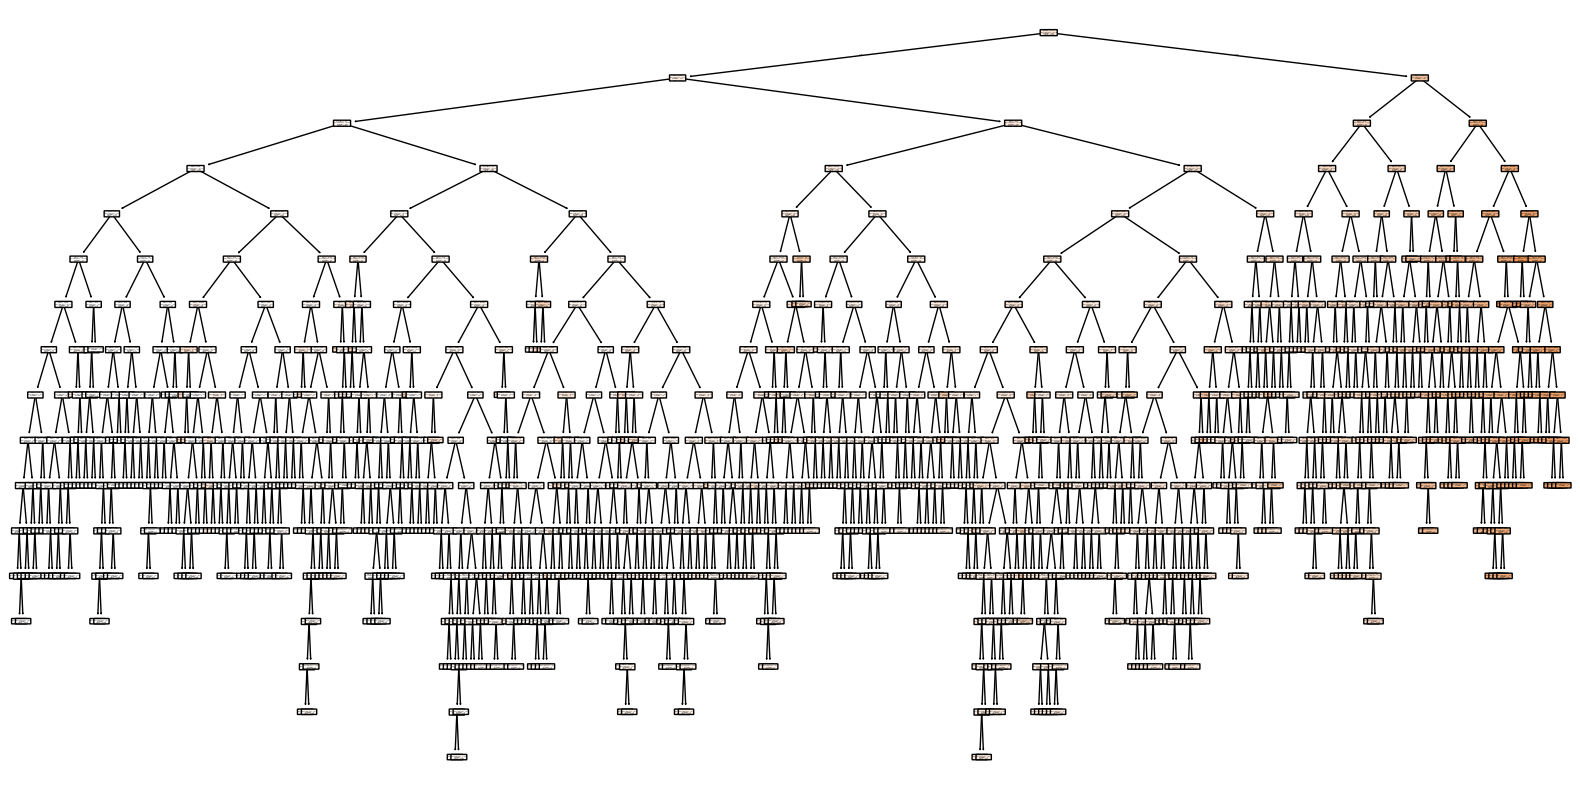

In [19]:
tree_index = 0
single_tree = rfr_model.estimators_[tree_index]

plt.figure(figsize=(20, 10))
plot_tree(single_tree, feature_names=X_train.columns, filled=True, rounded=True)
plt.show()

---
## Section 9 — Feature Importance

Feature importance answers: **"Which variables does the model rely on most when making predictions?"**

### How It Is Calculated (for tree-based models)
For every split in every tree, the model records how much that split reduced the prediction error. Features that cause the largest error reductions across all splits get the highest importance score. All scores are normalised to sum to 1.


### Why This Matters for Business

Feature importance is where statistics becomes strategy:
- The top 3 features (`smoker`, `age`, `bmi`) explain the vast majority of charge variation
- A pricing team can focus their risk assessment on these three factors
- A product team can design targeted wellness programmes for high-risk segments (smokers, high-BMI customers)

We plot importance for all three tree-based models (Decision Tree, Random Forest, XGBoost) to see whether they agree — consistent rankings across models increase confidence in the finding.

In [21]:
def plot_feature_importance(model, feature_names, model_name):
    feature_importance = pd.DataFrame(model.feature_importances_, index=feature_names, columns=["Importance"])
    feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    feature_importance.plot(kind='bar', legend=False, color='skyblue')
    plt.title(f'Feature Importance for {model_name}')
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.show()

<Figure size 1000x600 with 0 Axes>

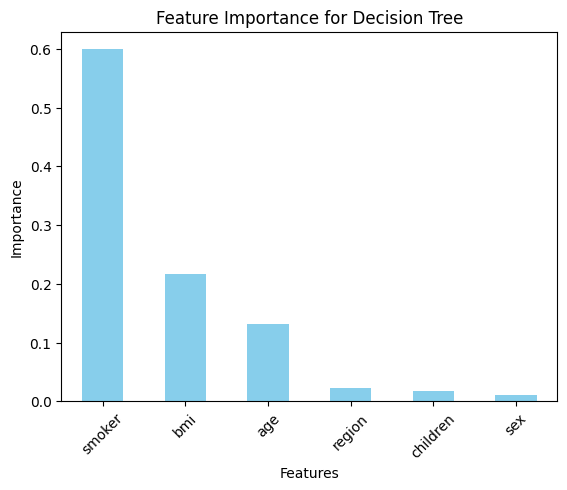

<Figure size 1000x600 with 0 Axes>

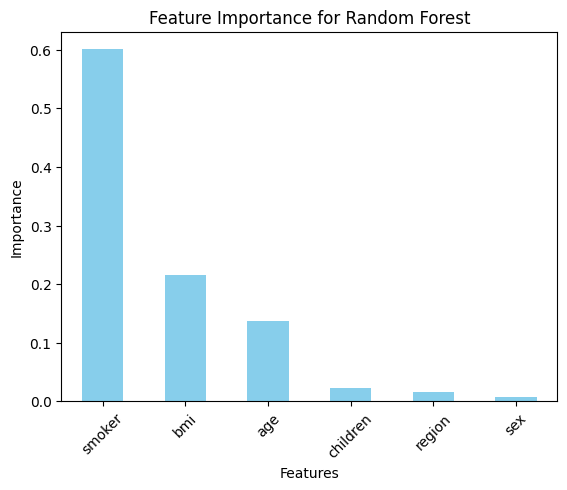

<Figure size 1000x600 with 0 Axes>

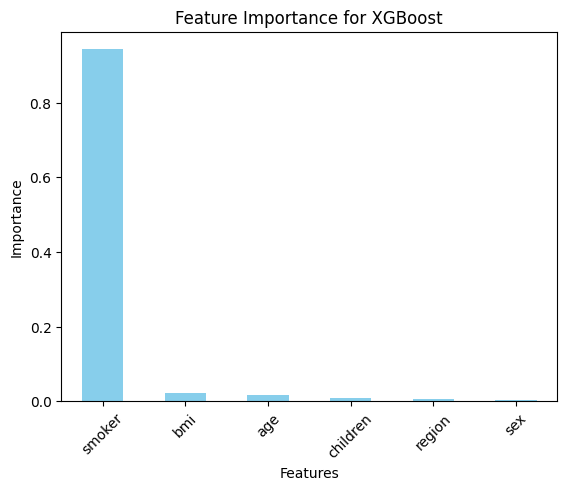

In [22]:
# Compares which features matter most across different models.

plot_feature_importance(dt_model, X_train.columns, "Decision Tree")
plot_feature_importance(rfr_model, X_train.columns, "Random Forest")
plot_feature_importance(xgb_model, X_train.columns, "XGBoost")

---
## Section 10 — Hyperparameter Tuning with GridSearchCV

### What Are Hyperparameters?

Hyperparameters are settings that control **how the model learns** — they are set by you *before* training starts and are not learned from the data. Choosing good hyperparameters can significantly improve model performance.

### The Hyperparameters We Tune (Random Forest)

| Hyperparameter | What It Controls | Trade-off |
|---|---|---|
| `n_estimators` | Number of trees to build (100, 200, 300) | More trees = more accurate but slower |
| `max_depth` | How deep each tree can grow (None, 10, 20, 30) | Deeper = more complex = risk of overfitting |
| `min_samples_split` | Min rows needed to split a node (2, 5, 10) | Higher = simpler, less overfitting |
| `min_samples_leaf` | Min rows in each leaf node (1, 2, 4) | Higher = smoother, more generalised predictions |
| `bootstrap` | Sample rows with replacement? (True/False) | True = more diversity between trees |

### How GridSearchCV Works

GridSearchCV tests **every possible combination** of these settings:

```
3 × 4 × 3 × 3 × 2 = 216 combinations
× 5 cross-validation folds
= 1,080 total model fits
```

**Cross-validation (cv=5):** Instead of a single train/test split, the training data is divided into 5 equal parts (folds). The model trains on 4 folds and validates on 1 — repeated 5 times with different validation folds. The average score is more reliable than a single split.

**`scoring='r2'`:** The combination with the highest average R² score across all 5 folds wins.

**`n_jobs=-1`:** Uses all available CPU cores in parallel — this is why tuning finishes in minutes instead of hours.

In [ ]:
# Hyperparameters control HOW a model learns.
# GridSearchCV tests many combinations to find the best performing model.
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],          # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],          # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],          # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],            # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]                # Whether bootstrap samples are used when building trees
}

GridSearchCV tries every combination in param_grid.

cv=5 → performs 5-fold cross-validation.

scoring='r2' → selects the model with highest R².

In [24]:
# Initialize the RandomForestRegressor
# rfr_model = RandomForestRegressor(random_state=42)

# Set up the grid search
grid_search = GridSearchCV(estimator=rfr_model, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='r2')

# Fit the grid search model to the training data
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END bootstrap=True, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tot

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True, False], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [25]:
# Shows the winning model settings + performance.
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best R-squared Score: {grid_search.best_score_}")

Best Hyperparameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best R-squared Score: 0.8363173643695732


---
## Section 11 — Applying the Best Tuned Model

### What `grid_search.best_estimator_` Gives Us

After GridSearchCV finishes testing all 1,080 combinations, `best_estimator_` returns the Random Forest model already configured with the winning hyperparameters:

```
bootstrap=True, max_depth=10, min_samples_leaf=4,
min_samples_split=10, n_estimators=300
```

We re-fit this best model on the full training set and evaluate it on the test set.


You retrain the best model and evaluate it again on the test set.

In [26]:
# Train the model using the best parameters
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

best_rfr_model = grid_search.best_estimator_

# Fit the best model on the training data
best_rfr_model.fit(X_train, y_train)

# Make predictions and evaluate the performance
y_pred_best = best_rfr_model.predict(X_test)
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

# Print the results
print(f"MAE: {mae_best}, MSE: {mse_best}, R2: {r2_best}")


MAE: 0.038861938891393236, MSE: 0.004786376584372034, R2: 0.8977678981793442


---
## Summary — Key Takeaways

### Model Comparison Results

| Model | MAE | MSE | R² | Verdict |
|---|---|---|---|---|
| Linear Regression | 0.0668 | 0.00904 | 0.807 | Good baseline |
| Decision Tree | 0.0477 | 0.01070 | 0.771 | Overfits — worst R² |
| **Random Forest** | **0.0411** | **0.00551** | **0.882** | **Best default model** |
| XGBoost | 0.0450 | 0.00616 | 0.868 | Strong — close to RF |
| **Tuned Random Forest** | **0.0389** | **0.00479** | **0.898** | **Best overall** |

### Lessons

1. **Data preparation is 80% of the work** — encoding, scaling, and splitting correctly determines whether your model can learn anything at all

2. **Always compare a simple model and a complex model** — Linear Regression as baseline, Random Forest or XGBoost as the complex model. If the simple model wins, your data may not support complexity

3. **Three metrics tell the full story** — MAE for average error, MSE for large error sensitivity, R² for overall explanatory power. Never report just one

4. **Feature importance connects the model to the business** — `smoker`, `age`, and `bmi` drive the predictions. These three variables should anchor any pricing or risk strategy

5. **Tuning refines but does not transform** — GridSearchCV improved R² from 0.882 to 0.898. Real gains come from better data and the right model choice, not tuning alone


The pipeline is identical: **clean → encode → scale → split → train → evaluate → interpret**.